In [15]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv("C:/Users/asus/Downloads/Chronic_Kidney_Disease_dirty.csv")
data.head

<bound method NDFrame.head of       PatientID  Age Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0             1   71      0          0                    0               2   
1             2   34      0          0                    1               3   
2             3   80      1          1                    0               1   
3             4   40      0          2                    0               1   
4             5   43      0          1                    1               2   
...         ...  ...    ...        ...                  ...             ...   
1737       1545   36      1          0                    0               1   
1738       1114   78      0          0                    1               2   
1739        535   33      0          2                    0               2   
1740        465   72      0          1                    1               2   
1741       1055   56      1          1                    2               1   

            BMI  Smok

In [16]:
# Overview
print("Shape:", data.shape)
print("\nColumn Names:\n", data.columns.tolist())

# Data types and missing values
data.info()
print("\nMissing Values:\n", data.isnull().sum())

# Quick numerical summary
data.describe()


Shape: (1742, 54)

Column Names:
 ['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins', 'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality', 'MedicalCheckupsFrequency', 'MedicationAdherence', 'HealthLite

,PatientID,Age,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy
count,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1606.000000,1742.000000,1742.000000,1742.000000,1742.000000,...,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000
mean,829.716992,54.997130,0.704937,0.981056,1.696900,28.176001,0.293915,9.985940,5.017052,5.055242,...,3.480099,3.519093,5.062209,49.752073,0.044776,0.101033,0.194030,2.004420,4.922703,5.145162
std,479.562135,22.513803,0.995203,0.778212,0.910076,11.047713,0.455684,5.797316,2.858073,2.876486,...,1.984650,2.018471,2.880495,27.847546,0.206871,0.301459,0.395566,1.144138,2.874078,2.893936
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021740,0.001186,0.002407,...,0.005171,0.006327,0.013697,0.087256,0.000000,0.000000,0.000000,0.001082,0.005392,0.004436
25%,417.250000,36.000000,0.000000,0.000000,1.000000,21.333588,0.000000,5.052971,2.546568,2.554799,...,1.771877,1.804583,2.553056,26.865147,0.000000,0.000000,0.000000,1.004896,2.440384,2.575005
50%,828.500000,54.500000,0.000000,1.000000,2.000000,27.655421,0.000000,9.960896,5.070114,5.063677,...,3.520244,3.572522,5.144405,49.058357,0.000000,0.000000,0.000000,2.046291,4.922760,5.173435
75%,1247.750000,73.000000,1.000000,2.000000,2.000000,34.156216,1.000000,14.949441,7.453485,7.522295,...,5.248292,5.247654,7.579709,73.917869,0.000000,0.000000,0.000000,2.953597,7.489837,7.726860
max,1659.000000,200.000000,3.000000,2.000000,3.000000,150.000000,1.000000,19.992713,9.998167,9.998927,...,6.997332,6.984636,9.998313,99.987510,1.000000,1.000000,1.000000,3.999469,9.992345,9.993754


In [17]:
import numpy as np 

# Replace missing numerical values with median
num_cols = data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

# Replace missing categorical values with mode
cat_cols = data.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [18]:
print("Duplicate Rows Before:", data.duplicated().sum())
data = data.drop_duplicates()
print("Duplicate Rows After:", data.duplicated().sum())


Duplicate Rows Before: 62
Duplicate Rows After: 0


In [20]:
# Gender
data['Gender'] = data['Gender'].astype(str).str.strip().str.upper()
data['Gender'] = data['Gender'].replace({'MALE':'M', 'FEMALE':'F', 'M':'M', 'F':'F'})

# DoctorInCharge cleanup
data['DoctorInCharge'] = data['DoctorInCharge'].astype(str).str.strip()
data['DoctorInCharge'] = data['DoctorInCharge'].replace({
    'Confidentail': 'Confidential', 'Confdential': 'Confidential',
    'Confidential#': 'Confidential', 'Confidentail ': 'Confidential'
})


In [22]:
# Replace unrealistic age, BMI, serum creatinine, etc.
data.loc[(data['Age'] < 1) | (data['Age'] > 120), 'Age'] = data['Age'].median()
data.loc[(data['BMI'] < 10) | (data['BMI'] > 60), 'BMI'] = data['BMI'].median()
data.loc[(data['SerumCreatinine'] < 0.2) | (data['SerumCreatinine'] > 10), 'SerumCreatinine'] = data['SerumCreatinine'].median()
data.loc[(data['GFR'] < 5) | (data['GFR'] > 150), 'GFR'] = data['GFR'].median()


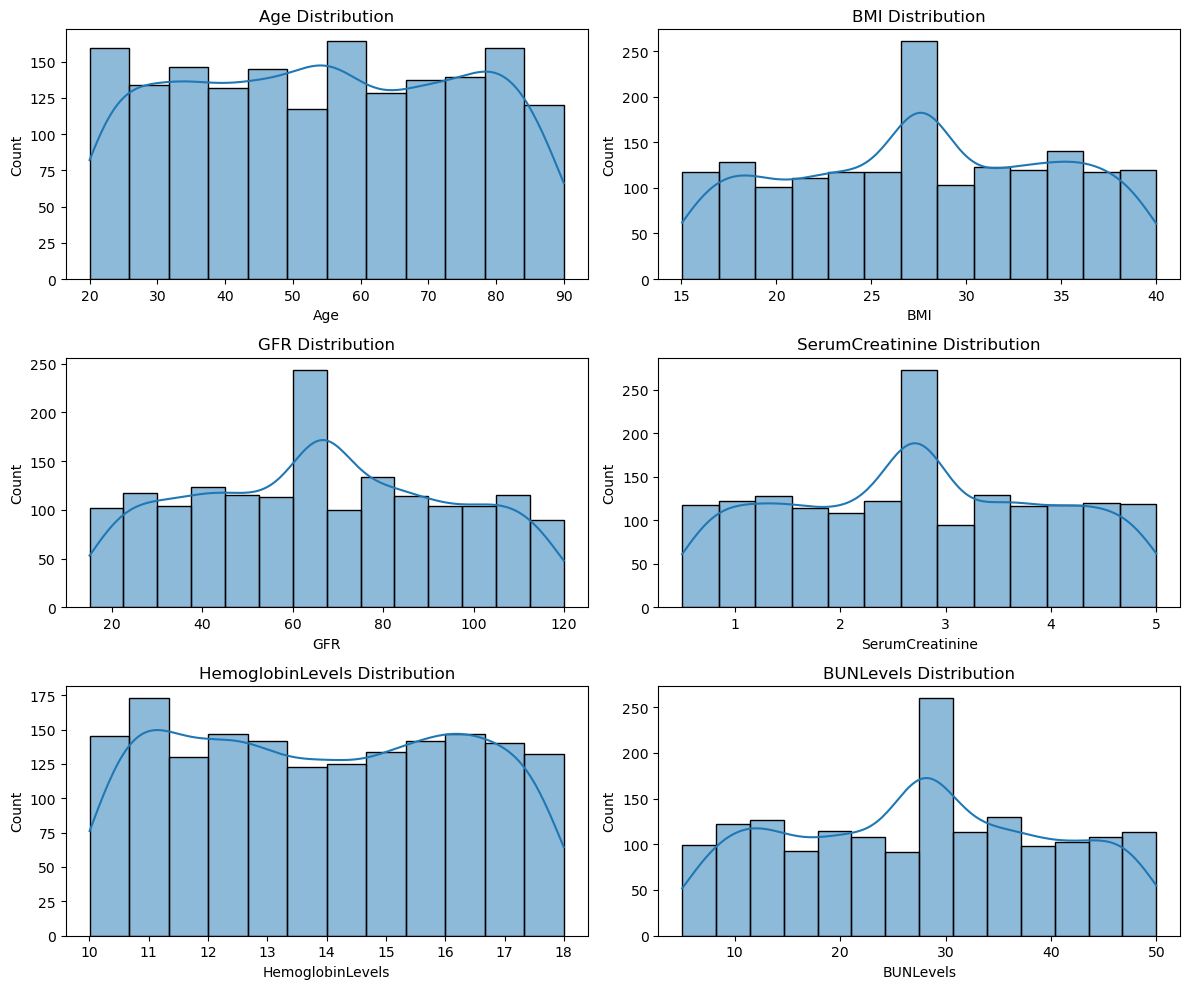

In [23]:
cols = ['Age', 'BMI', 'GFR', 'SerumCreatinine', 'HemoglobinLevels', 'BUNLevels']

plt.figure(figsize=(12,10))
for i, col in enumerate(cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(data[col], kde=True)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


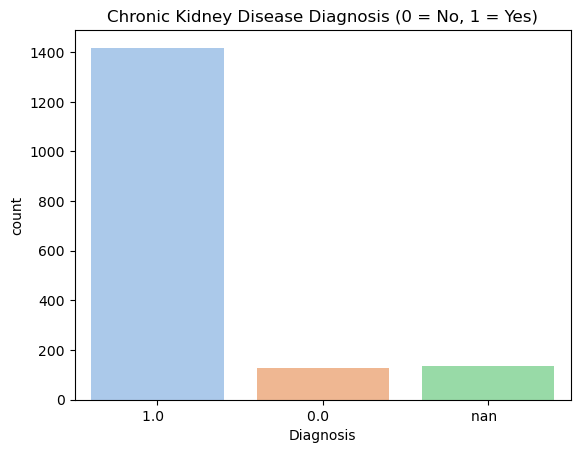

In [24]:
sns.countplot(x='Diagnosis', data=data, palette='pastel')
plt.title('Chronic Kidney Disease Diagnosis (0 = No, 1 = Yes)')
plt.show()


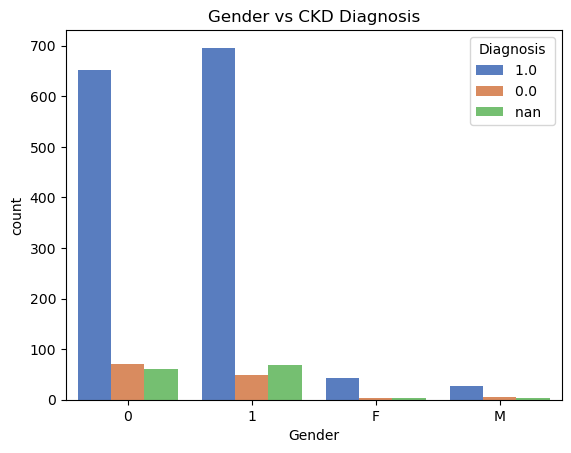

In [25]:
sns.countplot(x='Gender', hue='Diagnosis', data=data, palette='muted')
plt.title('Gender vs CKD Diagnosis')
plt.show()


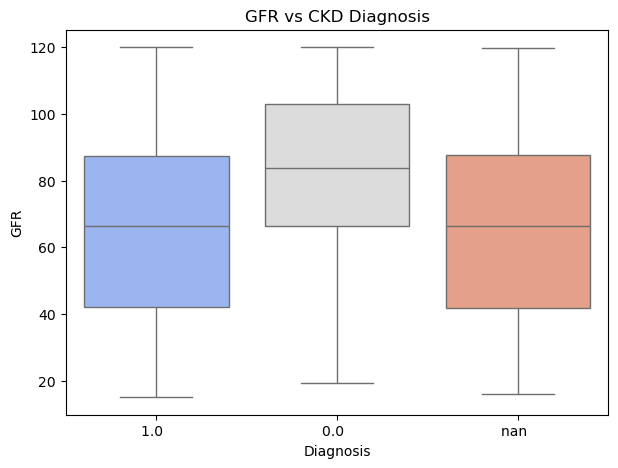

In [26]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Diagnosis', y='GFR', data=data, palette='coolwarm')
plt.title('GFR vs CKD Diagnosis')
plt.show()


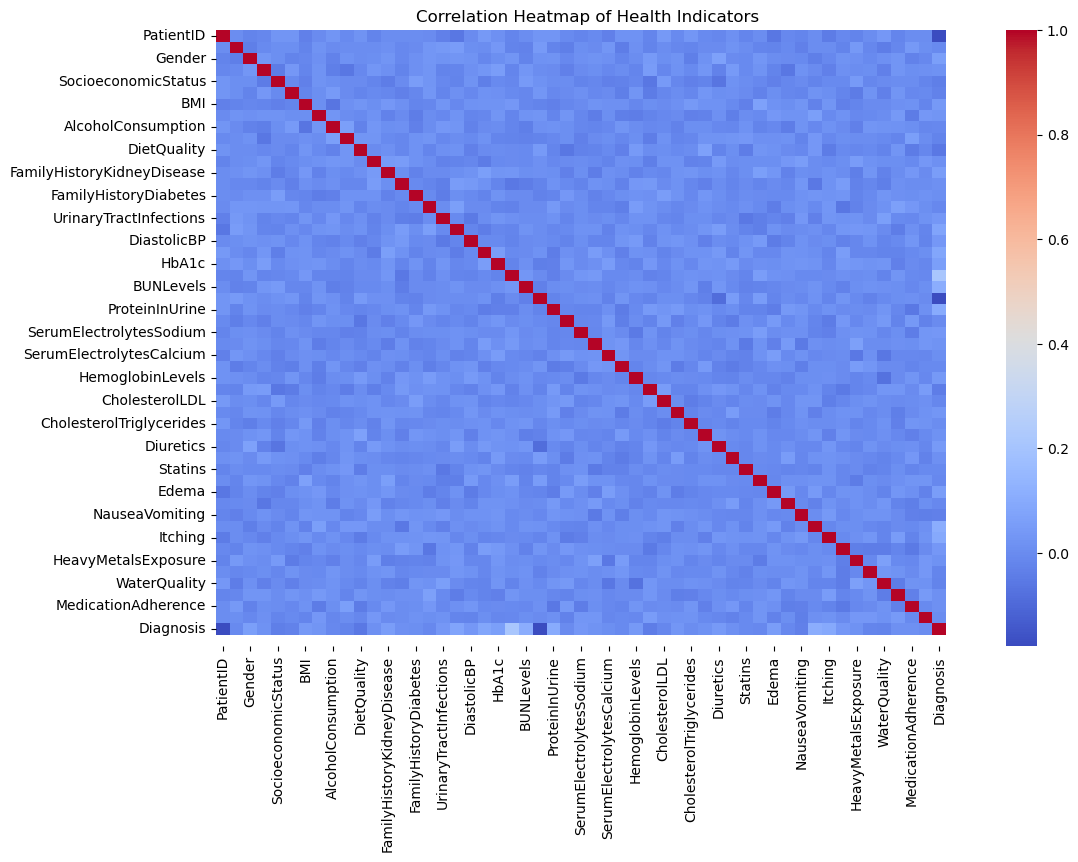

In [27]:
numeric_data = data.copy()
for col in numeric_data.columns:
    numeric_data[col] = pd.to_numeric(numeric_data[col], errors='coerce')

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Health Indicators')
plt.show()


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select important predictors
X = data[['Age', 'BMI', 'GFR', 'SerumCreatinine', 'HemoglobinLevels', 'BUNLevels']]
y = data['Diagnosis']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


✅ Model Accuracy: 81.85 %

Classification Report:
               precision    recall  f1-score   support

       0.0         0.00      0.00      0.00        28
       1.0         0.82      1.00      0.90       275
       nan         0.00      0.00      0.00        33

    accuracy                           0.82       336
   macro avg       0.27      0.33      0.30       336
weighted avg       0.67      0.82      0.74       336



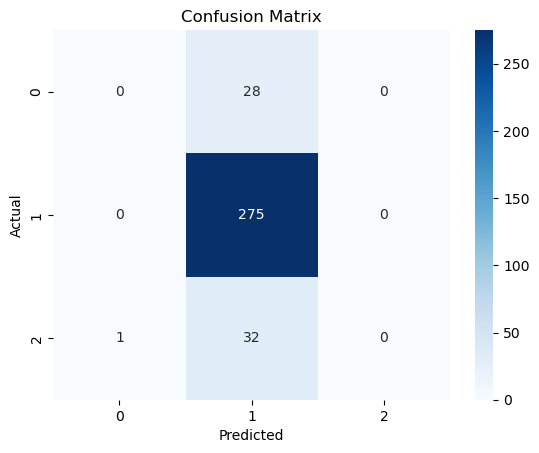

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("✅ Model Accuracy:", round(accuracy*100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


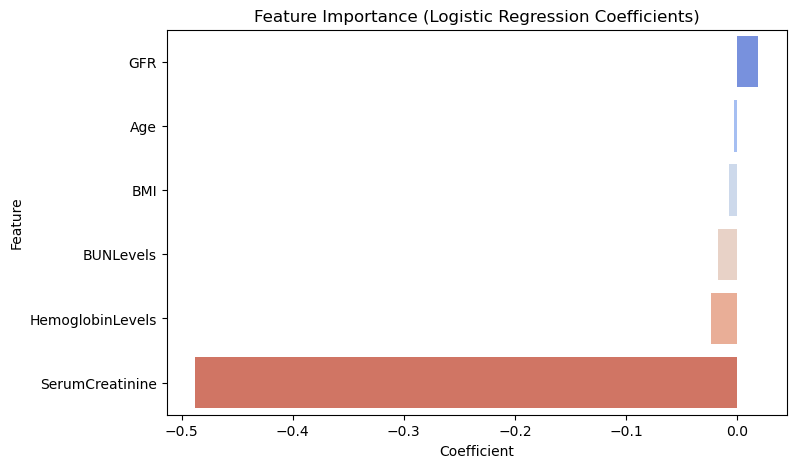

            Feature  Coefficient
2               GFR     0.019166
0               Age    -0.002439
1               BMI    -0.007171
5         BUNLevels    -0.016921
4  HemoglobinLevels    -0.023537
3   SerumCreatinine    -0.488103


In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()

print(importance)


In [32]:
data.to_csv('chronic_kidney_disease_cleaned.csv', index=False)
print("✅ Clean CKD dataset saved successfully!")


✅ Clean CKD dataset saved successfully!
